In [1]:
## mc grace velovi_py
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
from velovi import preprocess_data, VELOVI

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark = True

In [3]:
# ldata = scv.read("/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_rna_velocity_icn/ICN_data_from_Yingxin/velocyto/101122_ICN_E14_5.loom", cache=True)
# ldata.obs.index = [s[:-1] for s in list(ldata.obs.index)]
# ldata.obs.index = [s[17:] for s in list(ldata.obs.index)]

ldata = scv.read("/gpfs/gibbs/pi/zhao/jz874/jiazhao/Yvonne-ICNs/OIN_cellranger_out/ICN_E14_5/101122_ICN_E14_5/101122_ICN_E14_5/velocyto/101122_ICN_E14_5.loom", cache=True)
ldata.obs.index = [s[:-1] for s in list(ldata.obs.index)]
ldata.obs.index = [s[17:] for s in list(ldata.obs.index)]

res_path = "/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_rna_velocity_icn/prepare_data"
adata = scv.read(res_path + "/ICN_E14_3.h5ad", cache=True)
adata.obs["ident"] = adata.obs["Cell_States"]

adata.obs.index = [s[:-2] for s in list(adata.obs.index)]
adata.obs.index = [s[10:] for s in list(adata.obs.index)]

scv.utils.clean_obs_names(adata)
scv.utils.clean_obs_names(ldata)

adata = scv.utils.merge(adata, ldata)
adata

AnnData object with n_obs × n_vars = 3744 × 32245
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'integrated_snn_res.0.6', 'seurat_clusters', 'age', 'root', 'Cell_States', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'ident', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'Cell_States_colors', 'orig.ident_colors'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [4]:
scv.pp.filter_and_normalize(adata, min_shared_counts=10, n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

Filtered out 22361 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/velovi_py/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [5]:
adata = preprocess_data(adata)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [6]:
VELOVI.setup_anndata(adata, spliced_layer="Ms", unspliced_layer="Mu")
vae = VELOVI(adata)
vae.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: -1234.219. Signaling Trainer to stop.


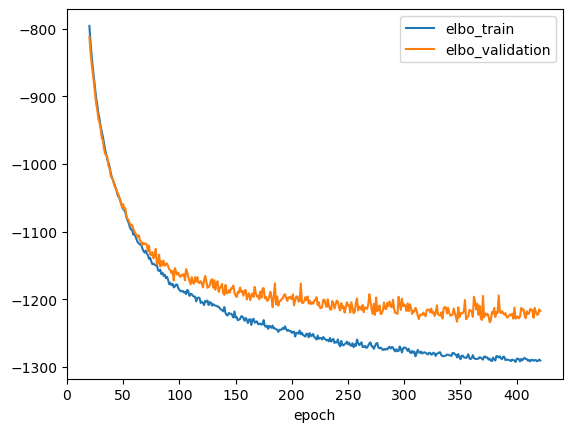

In [7]:
fig, ax = plt.subplots()
vae.history["elbo_train"].iloc[20:].plot(ax=ax, label="train")
vae.history["elbo_validation"].iloc[20:].plot(ax=ax, label="validation")
plt.legend()

In [8]:
def add_velovi_outputs_to_adata(adata, vae):
    latent_time = vae.get_latent_time(n_samples=25)
    velocities = vae.get_velocity(n_samples=25, velo_statistic="mean")

    t = latent_time
    scaling = 20 / t.max(0)

    adata.layers["velocity"] = velocities / scaling
    adata.layers["latent_time_velovi"] = latent_time

    adata.var["fit_alpha"] = vae.get_rates()["alpha"] / scaling
    adata.var["fit_beta"] = vae.get_rates()["beta"] / scaling
    adata.var["fit_gamma"] = vae.get_rates()["gamma"] / scaling
    adata.var["fit_t_"] = (
        torch.nn.functional.softplus(vae.module.switch_time_unconstr)
        .detach()
        .cpu()
        .numpy()
    ) * scaling
    # adata.layers["fit_t"] = latent_time.values * scaling[np.newaxis, :]
    adata.var['fit_scaling'] = 1.0

add_velovi_outputs_to_adata(adata, vae)

In [9]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/36 cores)


  0%|          | 0/3744 [00:00<?, ?cells/s]

    finished (0:00:04) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [10]:
adata.obs["clusters"] = adata.obs["Cell_States"]

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/velovi_py/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/velovi_py/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/gpfs/gibbs/project/zhao/jz874/prefix_grace_pkgs/velovi_py/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat

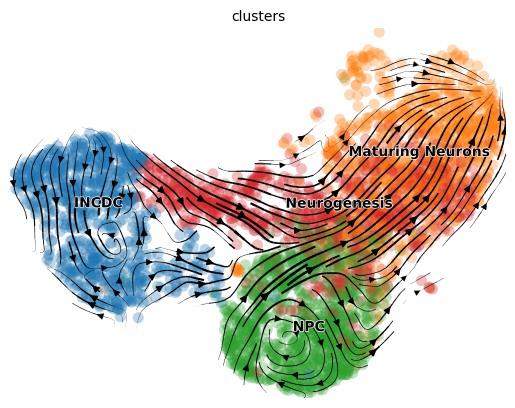

In [11]:
scv.pl.velocity_embedding_stream(adata, basis='X_umap')

In [12]:
adata

AnnData object with n_obs × n_vars = 3744 × 509
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'integrated_snn_res.0.6', 'seurat_clusters', 'age', 'root', 'Cell_States', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'ident', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'clusters'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling'
    uns: 'Cell_States_colors', 'orig.ident_colors', 'log1p', 'pca', 'neighbors', 'velocity_params', '_scvi_uuid', '_scvi_manager_uuid', 'velocity_graph', 'velocity_graph_neg', 'clusters_colors'
    obsm: 'X_umap', 'X_pca', 'velocity_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'l

In [13]:
adata.write("/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/oin_rna_velocity_icn/VeloVI/velovi_icn_e14_3.h5ad")